In [15]:
# Import libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [204]:
# Import data, Bin it, Clean numerical columns
fires = pd.read_csv('forestfires.csv')
bins = [0, 5, 40, 1100]
labels = [0,1,2]
fires.area = pd.cut(fires['area'], include_lowest=True, bins=bins, labels=labels)

fires.month = fires.month.astype('category').cat.codes
fires.day = fires.day.astype('category').cat.codes

In [209]:
# See how our data is spread out
fires.groupby(['area']).agg(['count'])
fires

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
,count,count,count,count,count,count,count,count,count,count,count,count
area,,,,,,,,,,,,
0,366,366,366,366,366,366,366,366,366,366,366,366
1,120,120,120,120,120,120,120,120,120,120,120,120
2,31,31,31,31,31,31,31,31,31,31,31,31


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0
1,7,4,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0
2,7,4,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0
3,8,6,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0
4,8,6,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,1,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,1
513,2,4,1,3,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,2
514,7,4,1,3,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,1
515,1,4,1,2,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0


In [255]:
# Create our data and target sets. Drop our initial fire set.
target = fires['area']
data = fires.drop(['area'], axis=1)
del fires

In [256]:
# Check for NaNs
data.isna().sum().max()

0

In [210]:
# Create training/test data
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size = .3, random_state=1)

In [239]:
# This is the value to beat. It is the counts of the majority class over the counts of every class.
y_test.describe().freq / y_test.count()

0.7243589743589743


Test Results
Accuracy: 0.7307692307692307
[[110   3   0]
 [ 30   4   0]
 [  8   1   0]]


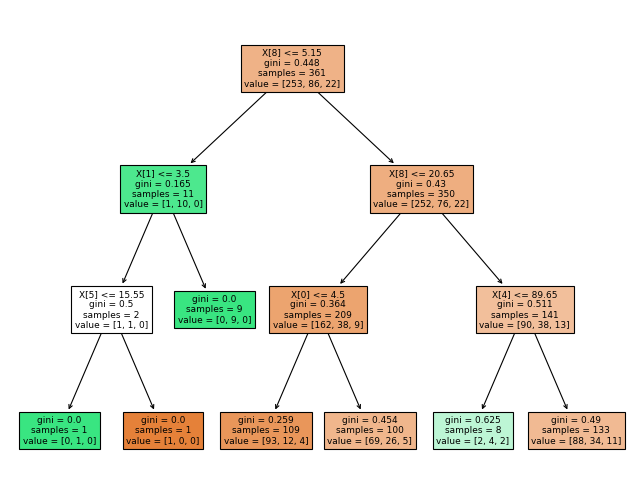

In [254]:
# Fit our first tree. It is misclassifying almost everything as the majority class how do we fix this?
'''
Hint we can use any of the following to deal with imbalanced classes. 
Under sample
Over sample
SMOTE
Bootstrapping (ensemble sampling of the data)
Feature weighting
'''
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('\nTest Results')
print('Accuracy: {}'.format(model.score(x_test, y_test)))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(10, 8), dpi= 80, facecolor='w', edgecolor='k')
plot_tree(model, filled=True)
plt.show();